# **Coastal Water Temperature Seasonality and Trend Regional Graphics**

Last updated on: 02/26/2026

## Overview
NOAA's CO-OPS collects trusted coastal data—including water temperature, tides, and currents—that helps keep navigation safe, supports commerce, and protects coastal communities and ecosystems. Since the early 1990s, over 220 water temperature sensors have been installed along U.S. coasts and in the Great Lakes. CO-OPS did an in-depth analysis on 174 stations with at least 20 years of data that is outlined in [Evaluation and quality control of CO-OPS coastal water temperature data](https://repository.library.noaa.gov/view/noaa/70917).

This notebook goes along side the scientific analysis of this data published in [ADD LINK HERE] with the primary objectives of demonstating the applicability and usefulness of measuring coastal water temperature at NOAA water level monitering stations in climate time scale studies, identifying the relationships between water temperature and sea level measured at the same stations, to compare water temperature at tide gauges against a well-known NOAA dataset used for water temperature: NOAA NESDIS OISST, and capture the local and regional patterns and variability and linear trends of water temperature along the US coasts.

## Prerequisites and running the Notebook
This notebook uses Python programming and users may run it either in **Google Colab** or **Jupyter Notebook**. To work offline, manage libraries and dependencies personally; using **Jupyter Notebook** is recommended. If you want cloud-based instant access, seamless co-operation and have access to good internet connection, **Google Colab** is the best option.

This notebook is designed so that people with limited familiarity with Python can run the notebook. To do so, go to the [github](https://github.com/NOAA-CO-OPS/coastal-water-temperature) page and click on the drop down menu under 'Code', then download the ZIP file. Extract the ZIP file and upload the Coastal_temp_seasonality_trend_regional_graphics.ipynb within in the Seasonality and Trends Publication Folder into [google colab](https://colab.research.google.com/). The code outputs 3 summary pngs. Lastly, click **Runtime** in the top menu and choose **Run All**. Then, when the 'Choose Files' box in step 2 becomes active, click on it and upload the MASTER_daily_clean_water_temp, MASTER_monthly_mean_water_temp station_summary_alltrends, and station_summary_seasonal_stats, and the station_list_water_temp_climatepaper csv(s). You will see a green check mark to the left of each cell as cells are sucessfully executed.

Users should be prepared to commit 30 minutes to familiarize themselves with the notebook, upload data, run code and examine results.

## Learning Outcomes
In this notebook users will be able to:
  1. Explore seasonality at 96 CO-OPS stations with high quality data.
  2. Explore the relationship between water and air temperature at different stations.
  2. Compare linear trends based on the period of record as seen in the publication.

## Data Sources and Documentation

All data comes from CO-OPS's sensors. Stations with water temperature data can be found via [CO-OPS Metadata API](https://api.tidesandcurrents.noaa.gov/mdapi/prod/webapi/stations.json?type=watertemp). 6-min water temperature data can be accessed through [CO-OPS Data API](https://api.tidesandcurrents.noaa.gov/api/prod/).

The QA/QC'd monthly averaged data is available called `MASTER_monthly_mean_water_temp.csv` where each column represents a station and each row a unique month and year combination.

The monthly averaged climatology is also available called `MASTER_Station_Monthly_Climatology` where each column represents a station and each row a month.

The `station_summary_seasonal_stats.csv` contains seasonal statistics shown in the paper, including:

  - Water and air temperature ranges
  - Climotological peak day for water and air temperature
  - Lag of days between the climotological peaks
  - Month of peak water temperature and water level
  - Lag of months between peak water temperature and water level

The `station_summary_alltrends.csv` contains metadata and trend information for water temperature and associated water level trends, including:
  - deploy and end dates of the water temperature for each station
  - water temperature trend, pval, ci, and vif
  - water level trend and vlm trend rate

The `station_list_water_temp_climatepaper` contains metadata for each station, including:

  - Region name and abbreviation (based on group median)
  - Data availability range
  - Data quality classification
  - OISST Comparision metadata

  ## Software
  This tutorial uses the following Python packages
  - pandas
  - matplotlib
  - datetime
  - os
  - zipfile
  - calplot
  - numpy
  - warnings



## **Step 1**
## Install and Load Packages
Lets check if you have these packages installed. If not, this cell will install them.

In [ ]:
# @title
import subprocess, sys
packages = ["os","pandas","seaborn","matplotlib","numpy"]
for package in packages:
    try:
        __import__(package)
    except ImportError:
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', package])

In [ ]:
import os
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import warnings
import matplotlib.gridspec as gridspec
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
warnings.filterwarnings("ignore", category=UserWarning, module="matplotlib.font_manager")

## **Step 2**
## Upload Data
Here we will upload the MASTER_Station_Monthly_Climatology.csv, MASTER_monthly_mean_water_temp.csv, station_summary_seasonal_stat.csv, station_summary_alltrends.csv and station_list_water_temp_climatepaper.csv. These files can be found on the CO-OPS [Github](https://github.com/NOAA-CO-OPS) page in the coastal-water-temperature [repository](https://github.com/NOAA-CO-OPS/coastal-water-temperature) with this notebook. If running on Google Colab, you can upload the files below. If running locally, the code will pull the data from your local repository.

In [ ]:
#@title Upload the three required CSVs if using google colab

#this can take a few minuates to load
try:
    from google.colab import files
    uploaded = files.upload()
except ModuleNotFoundError:
    print("User running script locally")

Saving station_summary_alltrends.csv to station_summary_alltrends.csv
Saving station_summary_seasonal_stats.csv to station_summary_seasonal_stats.csv
Saving MASTER_Station_Monthly_Climatology.csv to MASTER_Station_Monthly_Climatology.csv
Saving MASTER_monthly_mean_water_temp.csv to MASTER_monthly_mean_water_temp.csv
Saving station_list_water_temp_climatepaper.csv to station_list_water_temp_climatepaper.csv


✓ Calculated anomalies for 95 stations.

✓ Script finished. Plot saved to: regional_wt_anomaly_heatmaps_final.png


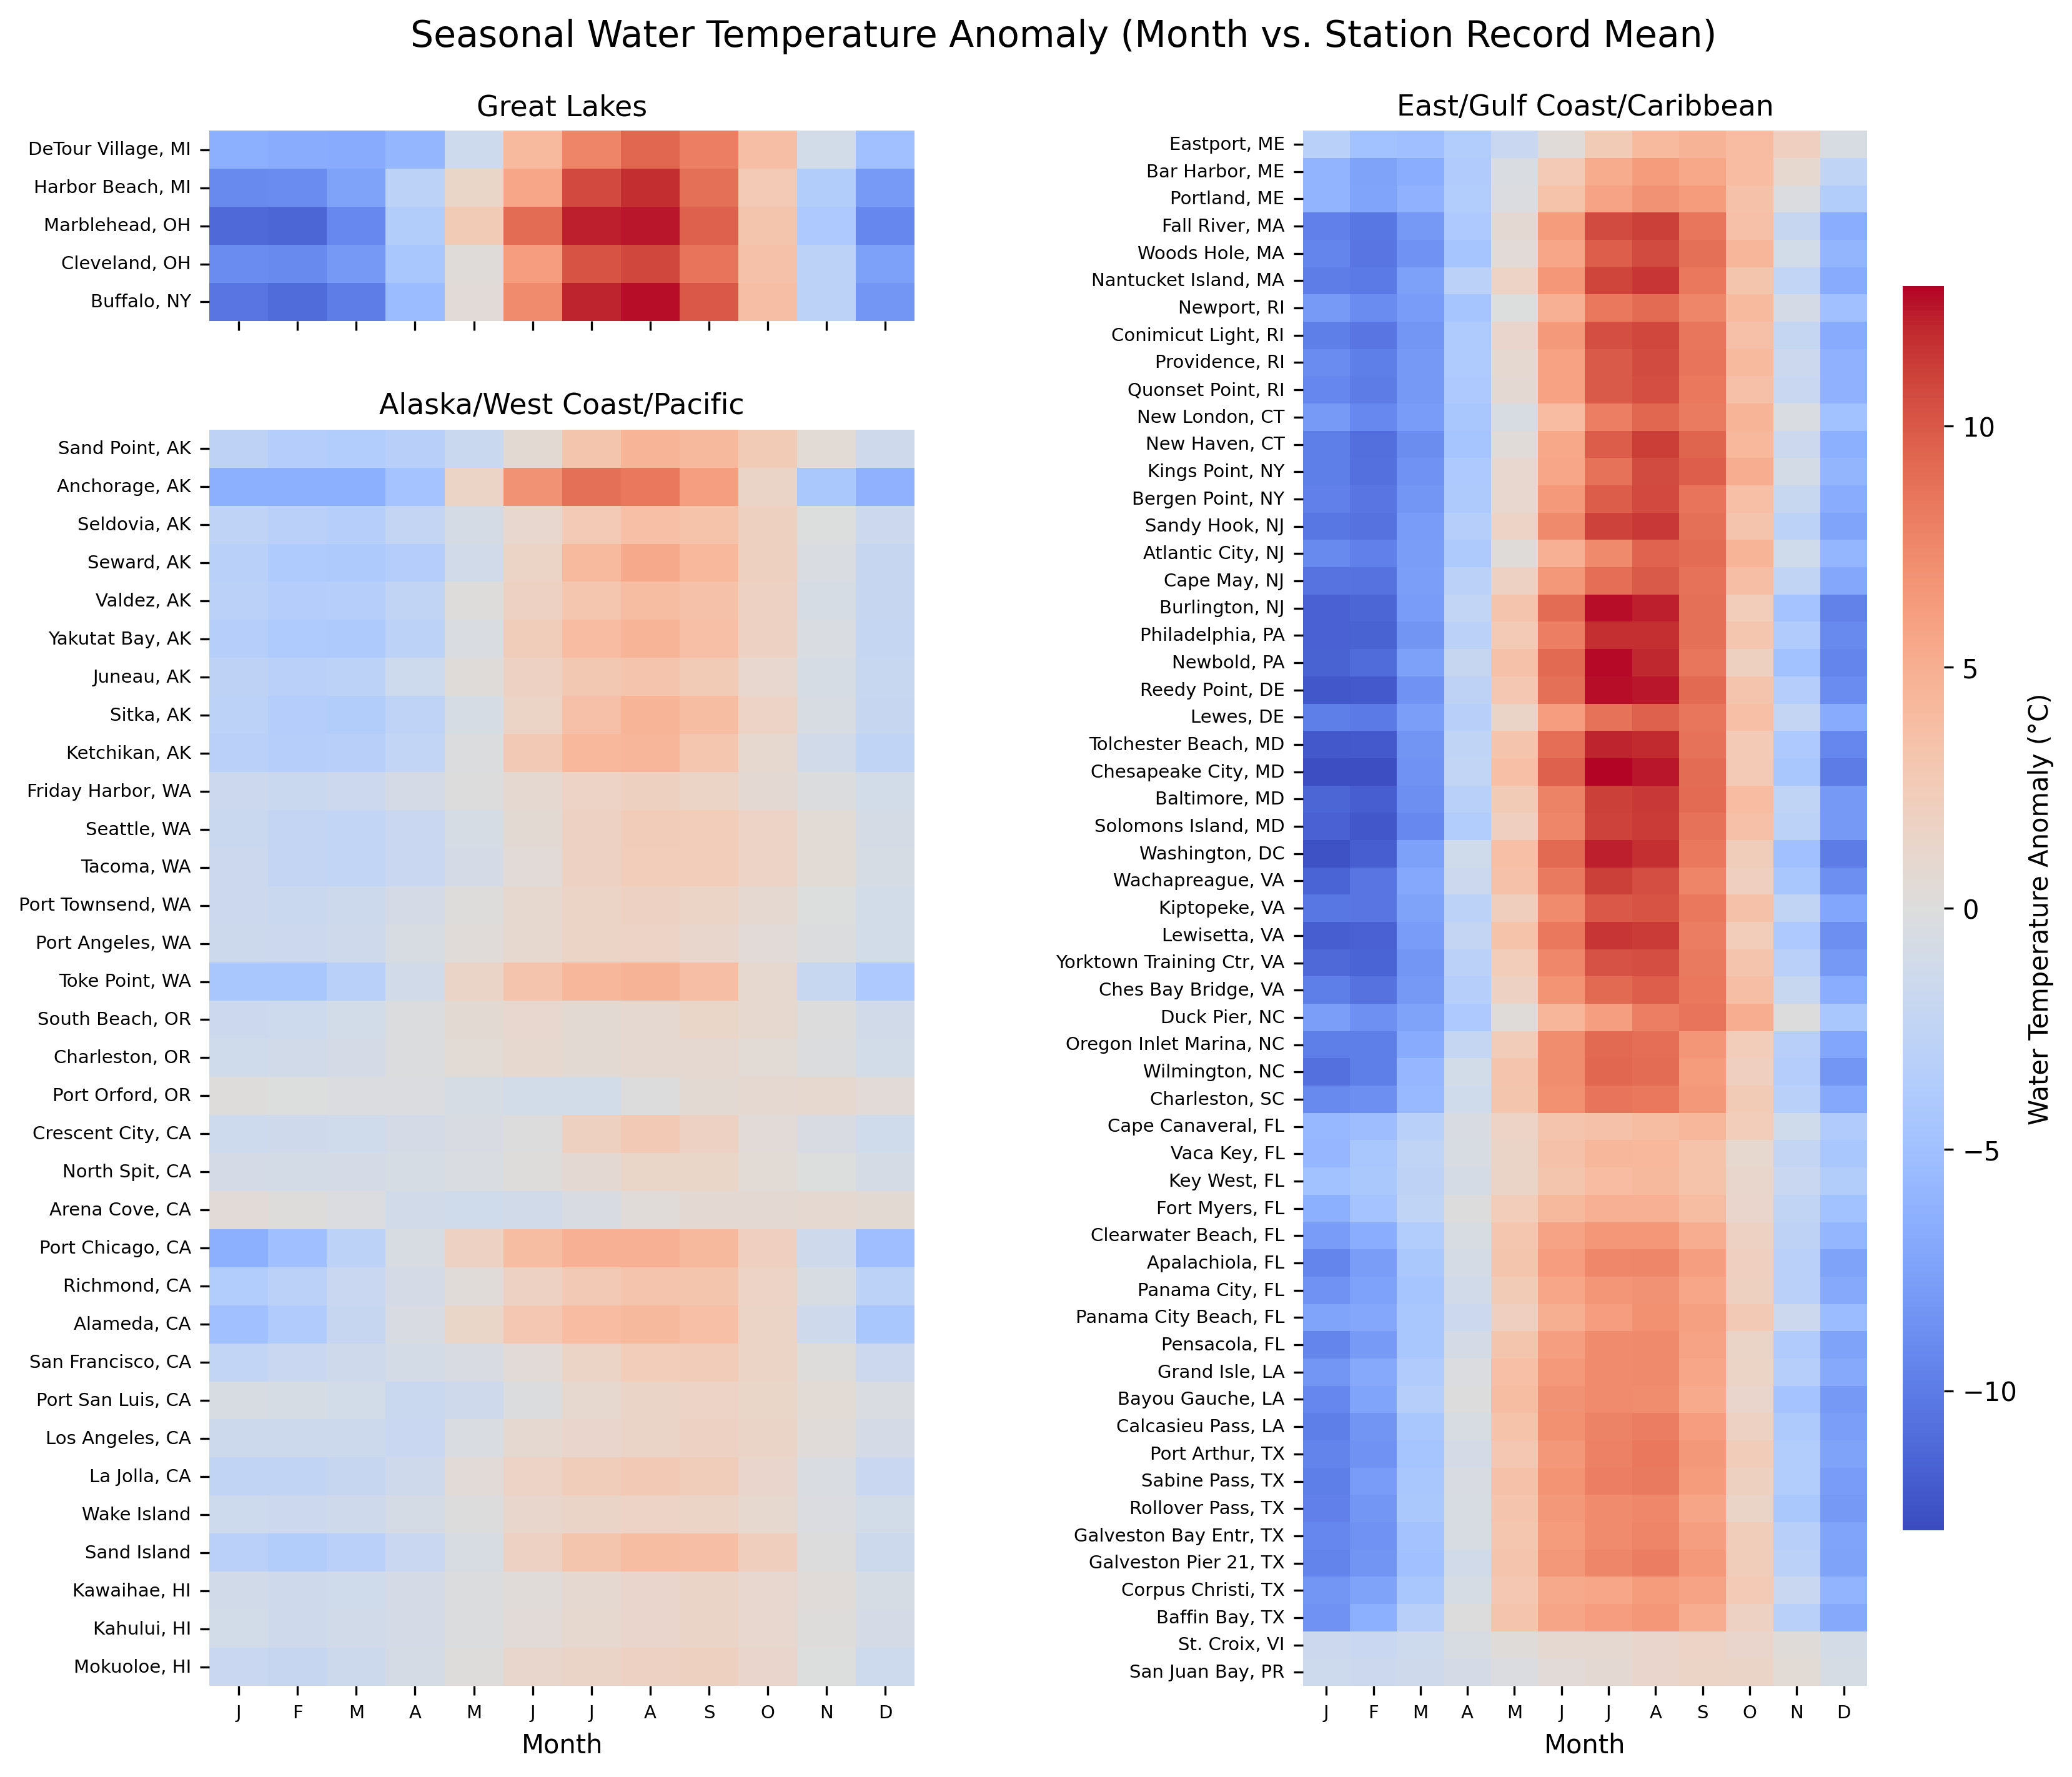

In [ ]:
# @title Monthly water temperature

# --- Configuration ---
MASTER_CLIM_CSV = 'MASTER_Station_Monthly_Climatology.csv'
MASTER_MEAN_CSV = 'MASTER_monthly_mean_water_temp.csv'
STATION_METADATA_CSV = 'station_list_water_temp_climatepaper.csv'
OUTPUT_PLOT_PATH = 'regional_wt_anomaly_heatmaps_final.png'

region_map = {
    "East/Gulf/CAR": ["Northeast", "Southeast", "East Gulf", "West Gulf", "Caribbean"],
    "Great Lakes": ["Great Lakes"],
    "Alaska/West/PAC": ["Alaska", "Northwest", "Southwest", "Pacific Islands"]
}
paneltitleFontSize = 11
suptitleFontsize = 14
axisFontSize = 10
ticklabelFontSize = 7

# --- Calculate Water Temperature Anomalies from Master Files ---

# Load data
df_clim = pd.read_csv(MASTER_CLIM_CSV) # Rows: Jan-Dec, Cols: Stations
df_means = pd.read_csv(MASTER_MEAN_CSV) # Rows: Time, Cols: Stations

# Calculate the overall long-term mean for every station in the record
# This gives us a single value per station to subtract from the climatology
long_term_station_averages = df_means.mean(numeric_only=True)

anomaly_data_list = []

# Process each station found in the Climatology file
for station_id in df_clim.columns:
    if station_id == 'Month':
        continue

    if station_id in long_term_station_averages.index:
        overall_mean = long_term_station_averages[station_id]

        # Calculate anomaly: Month Mean (from Climatology) - Total Record Mean
        for idx, month_val in enumerate(df_clim[station_id]):
            month_num = idx + 1 # 1 for Jan, 2 for Feb...
            anomaly = month_val - overall_mean

            anomaly_data_list.append({
                'station': station_id,
                'month': month_num,
                'anomaly': anomaly
            })

anomaly_df = pd.DataFrame(anomaly_data_list)
# Ensure station IDs are strings for matching
anomaly_df['station'] = anomaly_df['station'].astype(str)
print(f"✓ Calculated anomalies for {len(anomaly_df['station'].unique())} stations.")

# --- Prepare Data for Regional Plotting ---
meta_df = pd.read_csv(STATION_METADATA_CSV)
meta_df['id'] = meta_df['id'].astype(str)

merged_df = pd.merge(anomaly_df, meta_df[['id', 'master_region', 'display_name']], left_on='station', right_on='id')

heatmap_data = merged_df.pivot_table(
    index=['id', 'master_region', 'display_name'],
    columns='month',
    values='anomaly'
)

# --- Reusable Plotting Function ---
def plot_heatmap_panel(ax, data, title, vmin, vmax, show_cbar=False, show_xlabel=False):
    """Helper function to draw a heatmap panel for a given region."""
    station_labels = data.index.get_level_values('display_name')
    sns.heatmap(data, ax=ax, cmap="coolwarm", vmin=vmin, vmax=vmax, center=0,
                annot=False, cbar=show_cbar,
                cbar_kws={"shrink": 0.8, "aspect": 30, "label": "Water Temperature Anomaly (°C)"})

    ax.set_title(title, fontsize=paneltitleFontSize)
    ax.set_yticks(np.arange(len(station_labels)) + 0.5)
    ax.set_yticklabels(station_labels, fontsize=ticklabelFontSize, rotation=0)
    ax.set_ylabel("")

    month_labels = ['J', 'F', 'M', 'A', 'M', 'J', 'J', 'A', 'S', 'O', 'N', 'D']
    ax.set_xticks(np.arange(12) + 0.5)
    ax.set_xticklabels(month_labels if show_xlabel else [], fontsize=ticklabelFontSize, rotation=0)

    if show_xlabel:
        ax.set_xlabel("Month", fontsize=axisFontSize)
    else:
        ax.set_xlabel("")

# --- Create Figure and Plot Panels ---

# Filter data by region
data_east = heatmap_data[heatmap_data.index.get_level_values('master_region').isin(region_map["East/Gulf/CAR"])]
data_gl = heatmap_data[heatmap_data.index.get_level_values('master_region').isin(region_map["Great Lakes"])]
data_west = heatmap_data[heatmap_data.index.get_level_values('master_region').isin(region_map["Alaska/West/PAC"])]

# Reverse order for specific visual preference
data_gl = data_gl.iloc[::-1]
data_west = data_west.iloc[::-1]

v_abs_max = heatmap_data.abs().max().max()

# Initialize Figure
fig = plt.figure(figsize=(12, 10), dpi=300)

# Define GridSpec and pass the 'figure' object to it explicitly
gs = fig.add_gridspec(2, 2,
                      height_ratios=[max(len(data_gl), 2), max(len(data_west), 5)],
                      width_ratios=[1, 1],
                      hspace=0.15, wspace=0.55,
                      figure=fig) # Critical for layout managers

ax_east = fig.add_subplot(gs[:, 1])
ax_gl = fig.add_subplot(gs[0, 0])
ax_west = fig.add_subplot(gs[1, 0], sharex=ax_gl)

# Plot panels
plot_heatmap_panel(ax_east, data_east, "East/Gulf Coast/Caribbean", -v_abs_max, v_abs_max, show_cbar=True, show_xlabel=True)
plot_heatmap_panel(ax_gl, data_gl, "Great Lakes", -v_abs_max, v_abs_max)
plot_heatmap_panel(ax_west, data_west, "Alaska/West Coast/Pacific", -v_abs_max, v_abs_max, show_xlabel=True)

plt.setp(ax_gl.get_xticklabels(), visible=False)

# --- Final Touches and Save ---
fig.suptitle("Seasonal Water Temperature Anomaly (Month vs. Station Record Mean)",
             fontsize=suptitleFontsize, y=0.97)

fig.subplots_adjust(top=0.91, bottom=0.08, left=0.12, right=0.92, hspace=0.35, wspace=0.6)

try:
    # bbox_inches='tight' helps ensure everything fits in the saved image
    plt.savefig(OUTPUT_PLOT_PATH, bbox_inches='tight')
    print(f"\n✓ Script finished. Plot saved to: {OUTPUT_PLOT_PATH}")
except Exception as e:
    print(f"\n✗ Error saving plot: {e}")

plt.show()

✅ Data successfully merged.


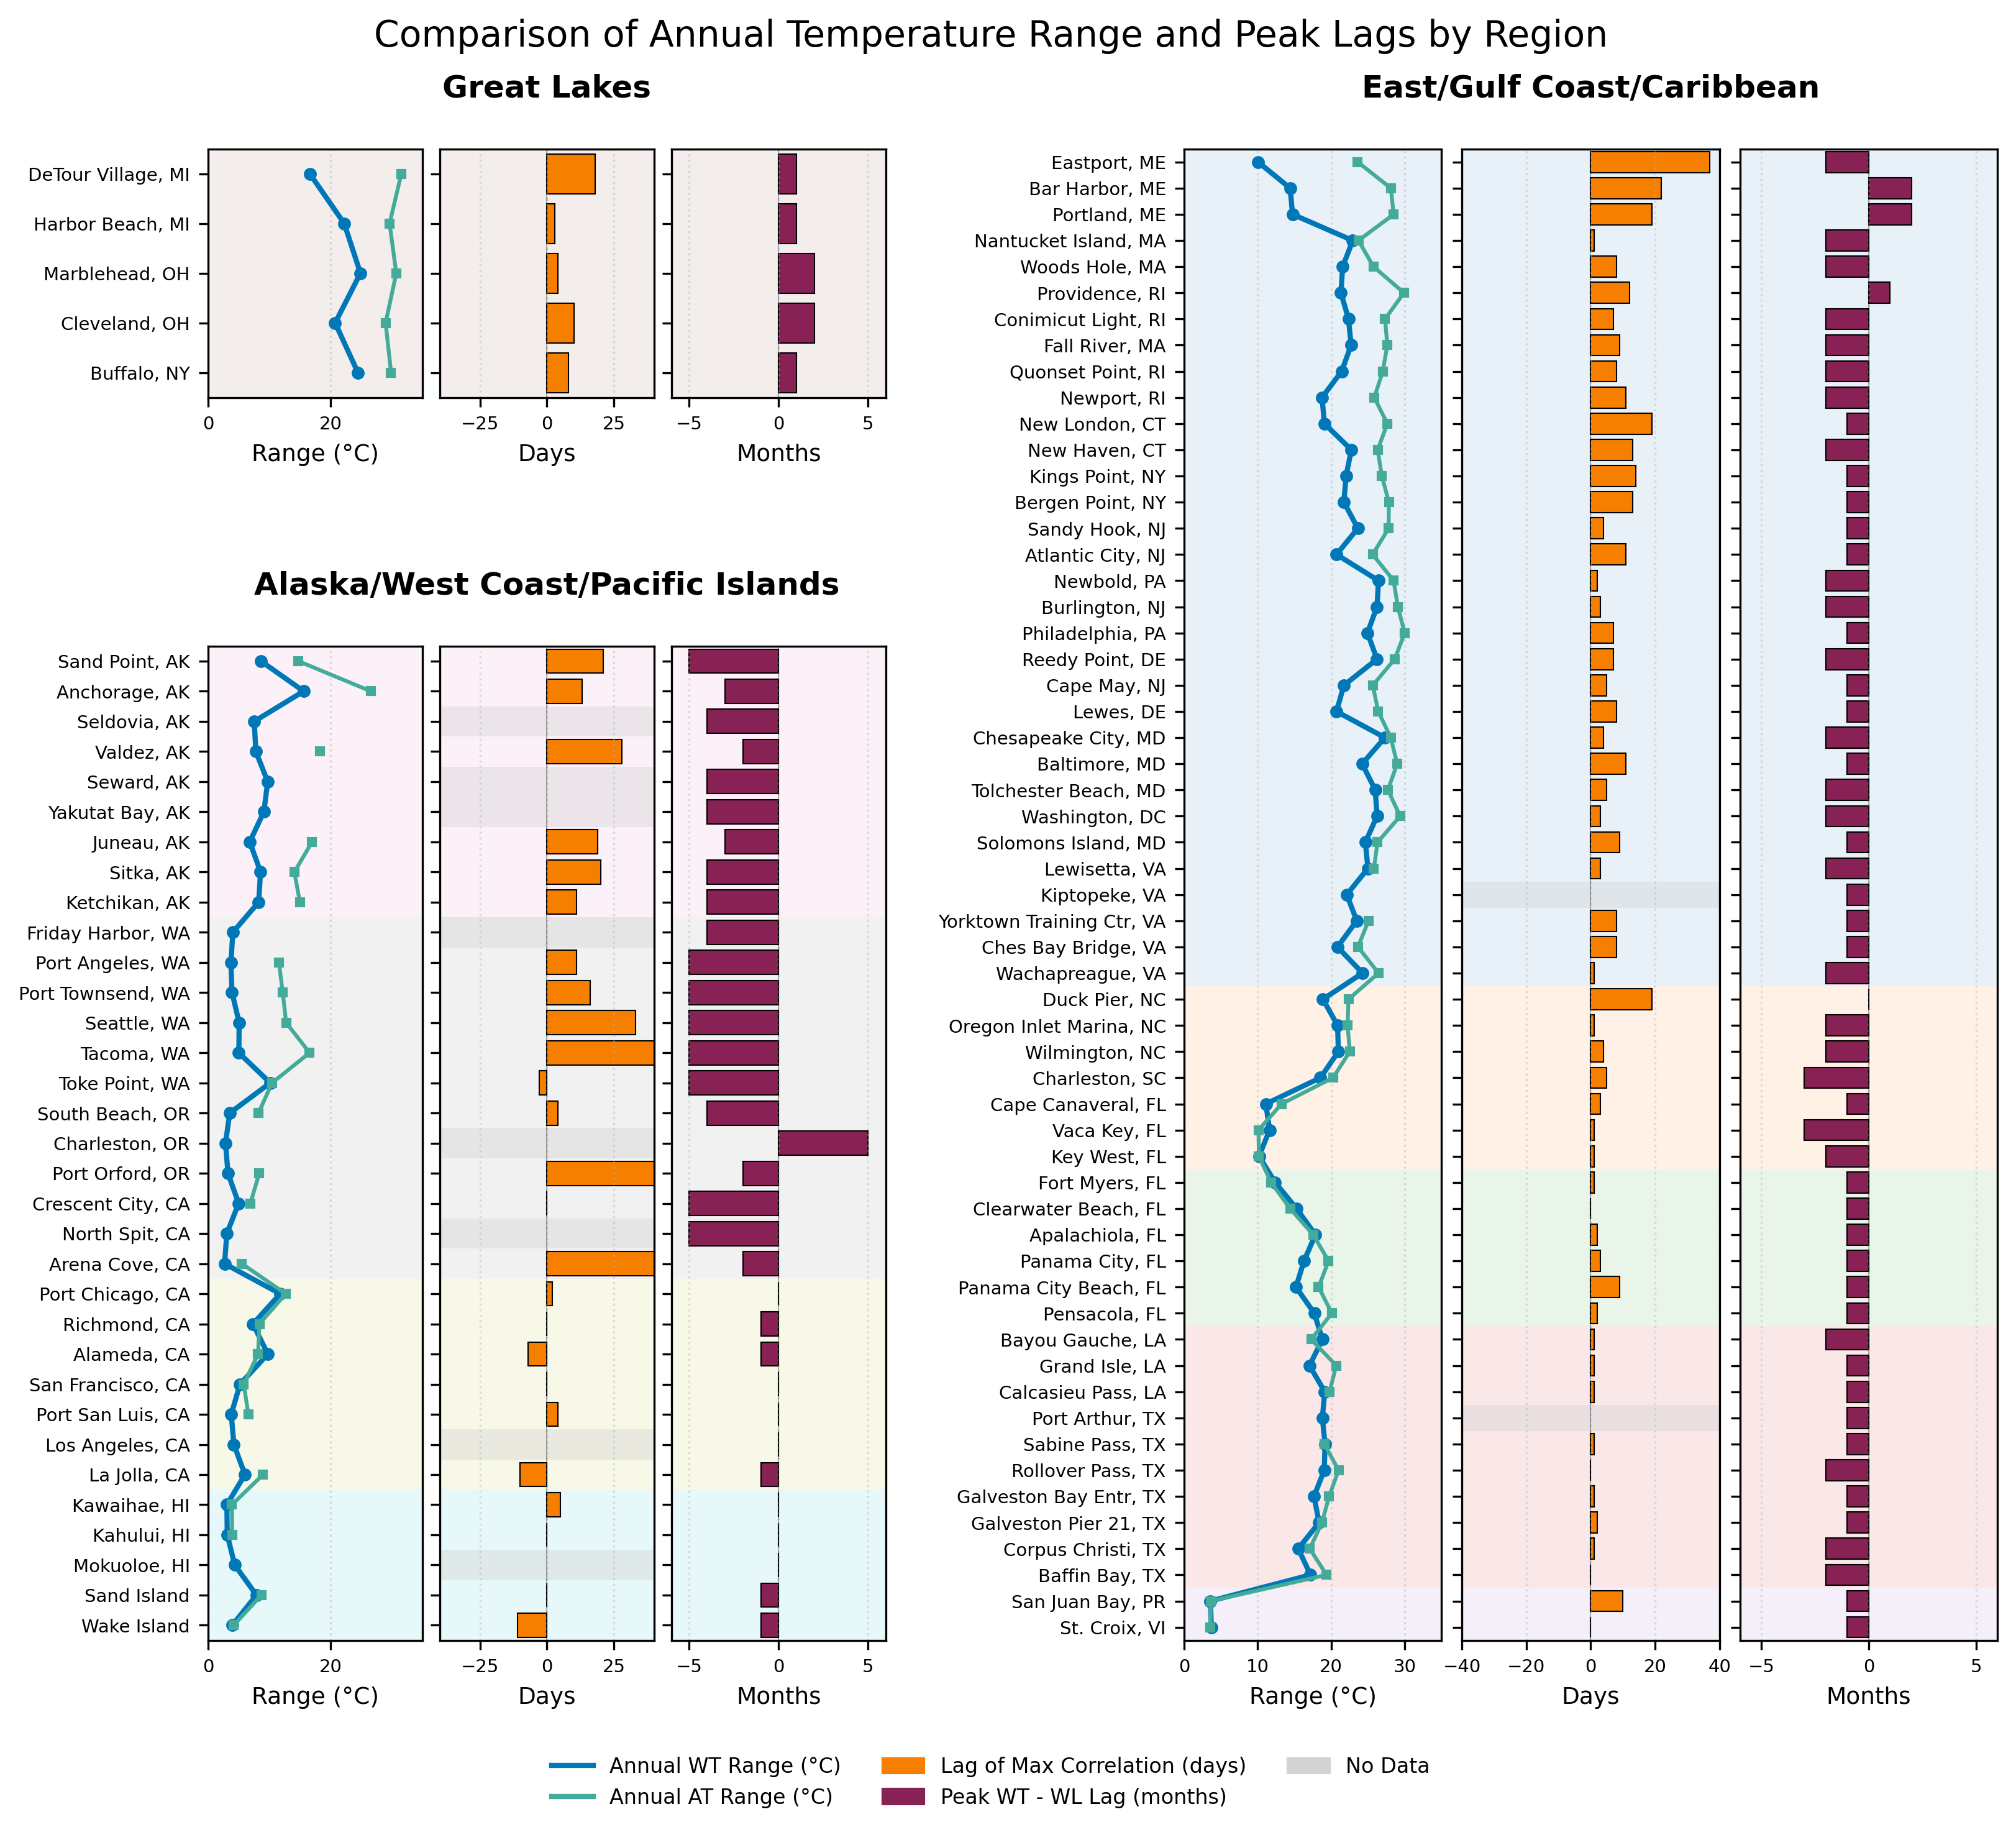

In [ ]:
# @title Summary graphic of seasonal variation metrics in coastal water temperature

STATS_CSV_PATH = 'station_summary_seasonal_stats.csv'
METADATA_CSV_PATH = 'station_list_water_temp_climatepaper.csv'
OUTPUT_PLOT_PATH = 'summary_seasonal_variation_metrics.png'

# Load the datasets
try:
    results_df = pd.read_csv(STATS_CSV_PATH)
    station_meta_df = pd.read_csv(METADATA_CSV_PATH)
except FileNotFoundError as e:
    print(f"Error: Could not find a required data file. {e}")
    exit()

# Prepare data for plotting by merging stats with metadata
try:
    # Drop conflicting columns from the stats file before merging
    cols_to_drop = ['display_name', 'name', 'master_region']
    results_df = results_df.drop(columns=cols_to_drop)

    results_df['Station'] = results_df['Station'].astype(str)
    station_meta_df['id'] = station_meta_df['id'].astype(str)

    station_meta_df.columns = station_meta_df.columns.str.strip()

    results_df = pd.merge(
        results_df,
        station_meta_df[['id', 'display_name', 'master_region']],
        left_on='Station',
        right_on='id',
        how='left'
    )
    results_df.drop('id', axis=1, inplace=True)
    print("✅ Data successfully merged.")

except KeyError as e:
    print(f"KeyError during setup: The column {e} was not found.")
    print("Please check that your CSV files contain the expected columns.")
    exit()

# This finds the region with the highest number of unique stations
max_stations_per_region = max(
    results_df[results_df['master_region'].isin(region_map[region_key])]['display_name'].nunique()
    for region_key in region_map
)

# --- Plotting Setup ---
# Define region groupings for panels
region_map = {
    "East/Gulf Coast/Caribbean": ["Northeast", "Southeast", "East Gulf", "West Gulf", "Caribbean"],
    "Great Lakes": ["Great Lakes"],
    "Alaska/West Coast/Pacific Islands": ["Alaska", "Northwest", "Southwest", "Pacific Islands"]
}

# Font sizes and colors
paneltitleFontSize = 12
suptitleFontsize = 14
axisFontSize = 9
ticklabelFontSize = 7

# Custom colorblind-safe palette for data
bar_colors = ['#0077b6', '#f77f00', '#882255']
air_temp_color = '#44AA99' # A distinct teal

# Get the tab10 colormap for background shading
cmap_bg = plt.get_cmap('tab10')

try:
    all_master_regions = list(station_meta_df['master_region'].unique())
    region_color_map = {
        region_name: cmap_bg(i % 10)
        for i, region_name in enumerate(all_master_regions)
    }
except NameError:
    print("Warning: station_meta_df not found for color mapping. Using defaults.")
    region_color_map = {} # Will default to gray in the function


# Create Figure (No constrained_layout here to avoid conflicts)
fig = plt.figure(figsize=(12, 10), dpi=300)

# Pass the figure to GridSpec explicitly
outer_gs = gridspec.GridSpec(2, 2, height_ratios=[1, 4], width_ratios=[1, 1.2],
                             hspace=0.4, wspace=0.4, figure=fig)

def plot_regional_panel(region_key, gs_locator):
    """
    Plots a regional panel with three subplots for water temperature metrics.
    """
    data_columns = ['Water Temp Range', 'Lag of Peak Correlation', 'Peak diff shift']
    x_labels = ['Range (°C)', 'Days', 'Months']

    # Filter data
    region_df = results_df[results_df['master_region'].isin(region_map[region_key])].copy()

    # Sort for consistent display
    region_df = region_df.iloc[::-1].reset_index(drop=True)
    n_stations = len(region_df)

    # Create the nested grid
    nested_gs = gridspec.GridSpecFromSubplotSpec(1, 3, subplot_spec=gs_locator, wspace=0.08)
    ax1 = fig.add_subplot(nested_gs[0, 0])
    ax2 = fig.add_subplot(nested_gs[0, 1], sharey=ax1)
    ax3 = fig.add_subplot(nested_gs[0, 2], sharey=ax1)
    axes = [ax1, ax2, ax3]

    ax2.set_title(region_key, fontsize=paneltitleFontSize, pad=20, fontweight='bold')

    # Background shading
    unique_regions = region_df['master_region'].unique()
    for idx, region_name in enumerate(unique_regions):
        region_indices = region_df[region_df['master_region'] == region_name].index
        min_idx, max_idx = region_indices.min(), region_indices.max()
        bg_color = region_color_map.get(region_name, 'gray')
        for ax in axes:
            ax.axhspan(ymin=min_idx - 0.5, ymax=max_idx + 0.5,
                      facecolor=bg_color, alpha=0.1, zorder=0)

    # Loop through subplots
    for i, ax in enumerate(axes):
        data_col = data_columns[i]
        color = bar_colors[i]

        # Missing data shading
        missing_mask = region_df[data_col].isna()
        for y_idx in region_df.index[missing_mask]:
            ax.axhspan(ymin=y_idx - 0.5, ymax=y_idx + 0.5,
                      facecolor='lightgray', alpha=0.4, linewidth=0)

        valid_mask = region_df[data_col].notna()

        if valid_mask.any():
            if i == 0: # Line Plot for Range
                ax.plot(region_df.loc[valid_mask, data_col], region_df.index[valid_mask],
                        color=color, linewidth=2, marker='o', markersize=4, label='WT Range')
                if 'Air Temp Range' in region_df.columns:
                    ax.plot(region_df['Air Temp Range'], region_df.index,
                            color=air_temp_color, linewidth=1.5, marker='s', markersize=3, label='AT Range')
            else: # Bar Plots
                ax.barh(region_df.index[valid_mask], region_df.loc[valid_mask, data_col],
                        color=color, edgecolor='black', linewidth=0.5)

        # Styling
        ax.axvline(0, linestyle='-', color='black', linewidth=0.5, alpha=0.3)
        ax.set_xlabel(x_labels[i], fontsize=axisFontSize)
        ax.tick_params(axis='x', labelsize=ticklabelFontSize)
        ax.grid(True, axis='x', linestyle=':', alpha=0.4)

        # Set specific x-limits
        if i == 0: ax.set_xlim(0, 35)
        elif i == 1: ax.set_xlim(-40, 40)
        elif i == 2: ax.set_xlim(-6, 6)

        # Y-axis scaling
        if region_key == "East/Gulf Coast/Caribbean":
            ax.set_ylim(-0.5, max_stations_per_region - 0.5)
        else:
            ax.set_ylim(-0.5, n_stations - 0.5)

    # Clean up Y-labels
    ax1.set_yticks(region_df.index)
    ax1.set_yticklabels(region_df['display_name'], fontsize=ticklabelFontSize)
    plt.setp(ax2.get_yticklabels(), visible=False)
    plt.setp(ax3.get_yticklabels(), visible=False)

# --- Execute ---
plot_regional_panel("East/Gulf Coast/Caribbean", outer_gs[:, 1])
plot_regional_panel("Great Lakes", outer_gs[0, 0])
plot_regional_panel("Alaska/West Coast/Pacific Islands", outer_gs[1, 0])

# --- Final Layout ---
fig.suptitle("Comparison of Annual Temperature Range and Peak Lags by Region", fontsize=suptitleFontsize, y=0.99)

# Use subplots_adjust instead of tight_layout to stop the warnings
fig.subplots_adjust(left=0.15, right=0.95, top=0.92, bottom=0.12, wspace=0.4, hspace=0.4)

legend_handles = [
    # Handle for the Water Temp line (solid)
    Line2D([0], [0], color=bar_colors[0], linestyle='-',
           linewidth=2, label='Annual WT Range (°C)'),

    # Handle for the Air Temp line (solid teal)
    Line2D([0], [0], color='#44AA99', linestyle='-',
           linewidth=2, label='Annual AT Range (°C)'),

    # Handle for the Lag (Days) bar
    Patch(color=bar_colors[1], label='Lag of Max Correlation (days)'),

    # Handle for the Peak Lag (Months) bar
    Patch(color=bar_colors[2], label='Peak WT - WL Lag (months)'),

    # Handle for the 'No Data' shaded area
    Patch(color='lightgray', label='No Data')
]
# Legend positioning (Manual coordinates to ensure it stays below the plots)
fig.legend(handles=legend_handles, loc='lower center', ncol=3, fontsize=8,
           frameon=False, bbox_to_anchor=(0.5, 0.02))

plt.savefig(OUTPUT_PLOT_PATH, bbox_inches='tight')
plt.show()

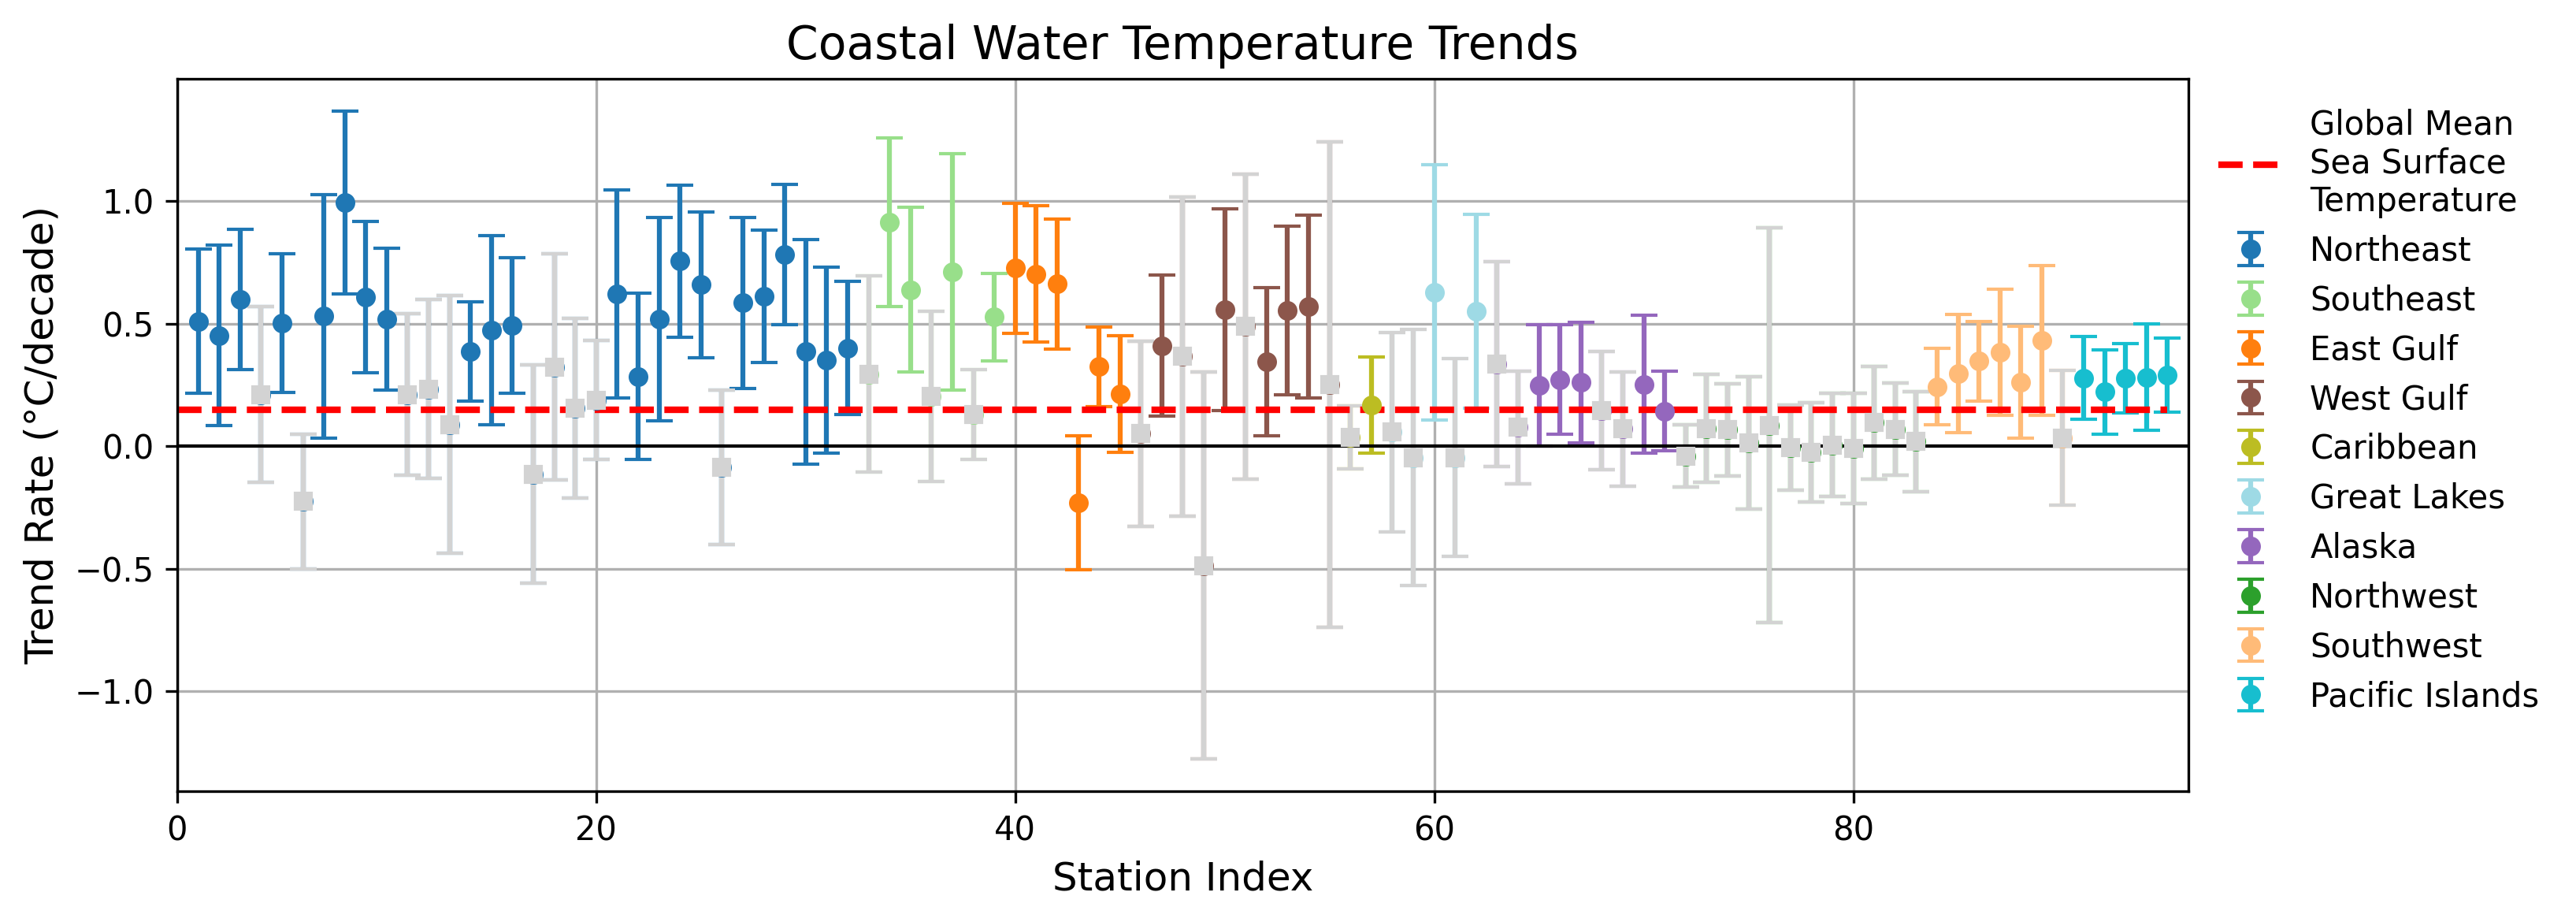

In [ ]:
# @title Summary graphic of coastal water temperature trends

STATS_CSV_PATH = 'station_summary_alltrends.csv'
METADATA_CSV_PATH = 'station_list_water_temp_climatepaper.csv'
OUTPUT_PLOT_PATH = 'summary_alltrends.png'

# Load the datasets
try:
    trends_all = pd.read_csv(STATS_CSV_PATH)
    station_meta_df = pd.read_csv(METADATA_CSV_PATH)
except FileNotFoundError as e:
    print(f"Error: Could not find a required data file. {e}")
    exit()

trends_all['trend'] = trends_all['wt_trend'] * 10  #convert to degC/decade
trends_all['wt_trend_ci'] = trends_all['wt_trend_ci'] * 10  #convert to degC/decade

# Generate plot with err bars (CI ranges), highlight stat sig trends

# First, subset only those that are NOT stat sig
trends_all_sig = trends_all[trends_all['wt_trend_pval'] > 0.101]

# For plotting, create colormap dictionary to standardize regional colors
regColor_tab20 = { 'Northeast':0, 'Southeast':5, 'East Gulf':2, \
               'West Gulf':10, 'Caribbean':16, 'Great Lakes':19, 'Alaska':8, \
               'Northwest':4, 'Southwest':3, 'Pacific Islands':18}

cmap = plt.colormaps.get_cmap('tab20')
zeroLW = 1
zeroColor = 'k'
xmax = len(trends_all)+1
xmin = 0


plt.figure(figsize=(11, 4),dpi=300)
plt.grid(True)
ax = plt.gca()
k = 0
for group in trends_all['master_region'].unique():
    group_data = trends_all[trends_all['master_region'] == group]
    ax.errorbar(group_data.index+1, group_data['trend'],yerr=group_data['wt_trend_ci'],markersize=5,fmt='o',capsize=4,color=cmap(regColor_tab20[group]), label=group)
    k = k + 1
ax.errorbar(trends_all_sig.index+1, trends_all_sig['trend'],yerr=trends_all_sig['wt_trend_ci'],markersize=5,fmt='s',capsize=4,color='lightgray')
plt.axhline(y=0, color=zeroColor, linestyle='-', linewidth=zeroLW)
plt.axvline(x=0, color=zeroColor, linestyle='-', linewidth=zeroLW)
plt.hlines(y=0.15, xmin=0, xmax=95, color='r', linewidth=2, linestyle='--', label='Global Mean\nSea Surface\nTemperature')
ax.set_xlim(0,len(trends_all)+1)
ax.set_xlabel('Station Index',fontsize=12)
ax.set_ylabel('Trend Rate (\N{DEGREE SIGN}C/decade)',fontsize=12)
ax.set_title('Coastal Water Temperature Trends',fontsize=14)
plt.legend(bbox_to_anchor=(1.0, 1.0), loc='upper left',facecolor='white',framealpha=0)
plt.tight_layout()
plt.savefig(OUTPUT_PLOT_PATH, bbox_inches='tight')
plt.show()


